In [1]:
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
df = pd.read_parquet("../data/clean/ecu911_emergencias_2021_2025.parquet")
print(df.shape)
df.head()


(4789409, 8)


,fecha,provincia,canton,cod_parroquia,parroquia,servicio,subtipo,cantidad_eventos
0,2022-04-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Gestión Sanitaria,Problemas En El Embarazo,1
1,2022-04-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Seguridad Ciudadana,Patrullaje Policial En El Sector Solicitado,1
2,2022-04-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Seguridad Ciudadana,Resguardo A Personas Que Traslada Valores A Ni...,1
3,2022-04-01,Azuay,Chordeleg,11150,"Chordeleg, Cabecera Cantonal",Seguridad Ciudadana,Patrullaje Policial En El Sector Solicitado,1
4,2022-04-01,Azuay,Cuenca,10150,"Cuenca, Cabecera Cantonal Y Capital Provincial.",Gestión De Riesgos,Amenazas Naturales,1


### Fechas

In [3]:
fecha_min = df['fecha'].min().strftime('%d/%m/%Y')
fecha_max = df['fecha'].max().strftime('%d/%m/%Y')
print(f"Rango de fechas: {fecha_min} → {fecha_max}")


Rango de fechas: 01/07/2021 → 31/08/2025


### Verificación de las provincias

In [4]:
df['provincia'].unique()

array(['Azuay', 'Bolivar', 'Carchi', 'Cañar', 'Chimborazo', 'Cotopaxi',
       'El Oro', 'Esmeraldas', 'Galapagos', 'Guayas', 'Imbabura', 'Loja',
       'Los Rios', 'Manabi', 'Morona Santiago', 'Napo', 'Orellana',
       'Pastaza', 'Pichincha', 'Santa Elena',
       'Santo Domingo De Los Tsachilas', 'Sucumbios', 'Tungurahua',
       'Zamora Chinchipe'], dtype=object)

In [5]:
print(len(df['provincia'].unique()))

24


### Analisis pre-eliminar

#### Servicios mas frecuentes

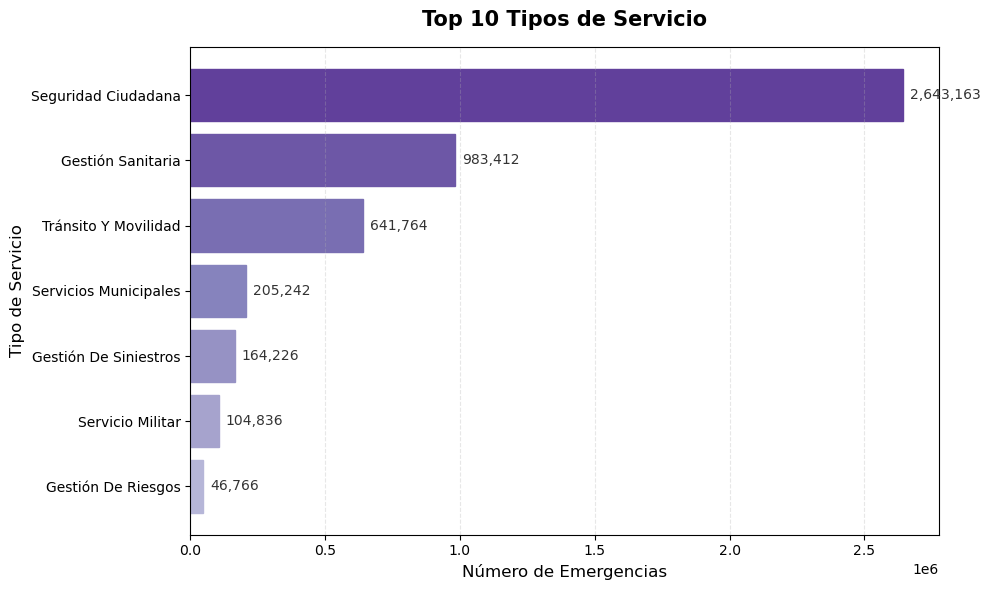

In [8]:
import matplotlib.pyplot as plt

# Ordenar y limitar al top 10
servicios = df["servicio"].value_counts().head(10).sort_values(ascending=True)

plt.figure(figsize=(10,6))
bars = plt.barh(servicios.index, servicios.values)

# Colores degradados (opcional)
for i, bar in enumerate(bars):
    bar.set_color(plt.cm.Purples(0.4 + i/15))  # tono violeta degradado

# Etiquetas y título
plt.title("Top 10 Tipos de Servicio", fontsize=15, weight="bold", pad=15)
plt.xlabel("Número de Emergencias", fontsize=12)
plt.ylabel("Tipo de Servicio", fontsize=12)

# Mostrar valores al final de cada barra
for i, v in enumerate(servicios.values):
    plt.text(v + max(servicios.values)*0.01, i, f"{v:,}", va="center", fontsize=10, color="#333")

# Mejoras visuales
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/fig/top10_servicios.png", bbox_inches="tight", transparent=False)

plt.show()


In [9]:
df["servicio"].unique()

array(['Gestión Sanitaria', 'Seguridad Ciudadana', 'Gestión De Riesgos',
       'Gestión De Siniestros', 'Servicios Municipales',
       'Tránsito Y Movilidad', 'Servicio Militar'], dtype=object)

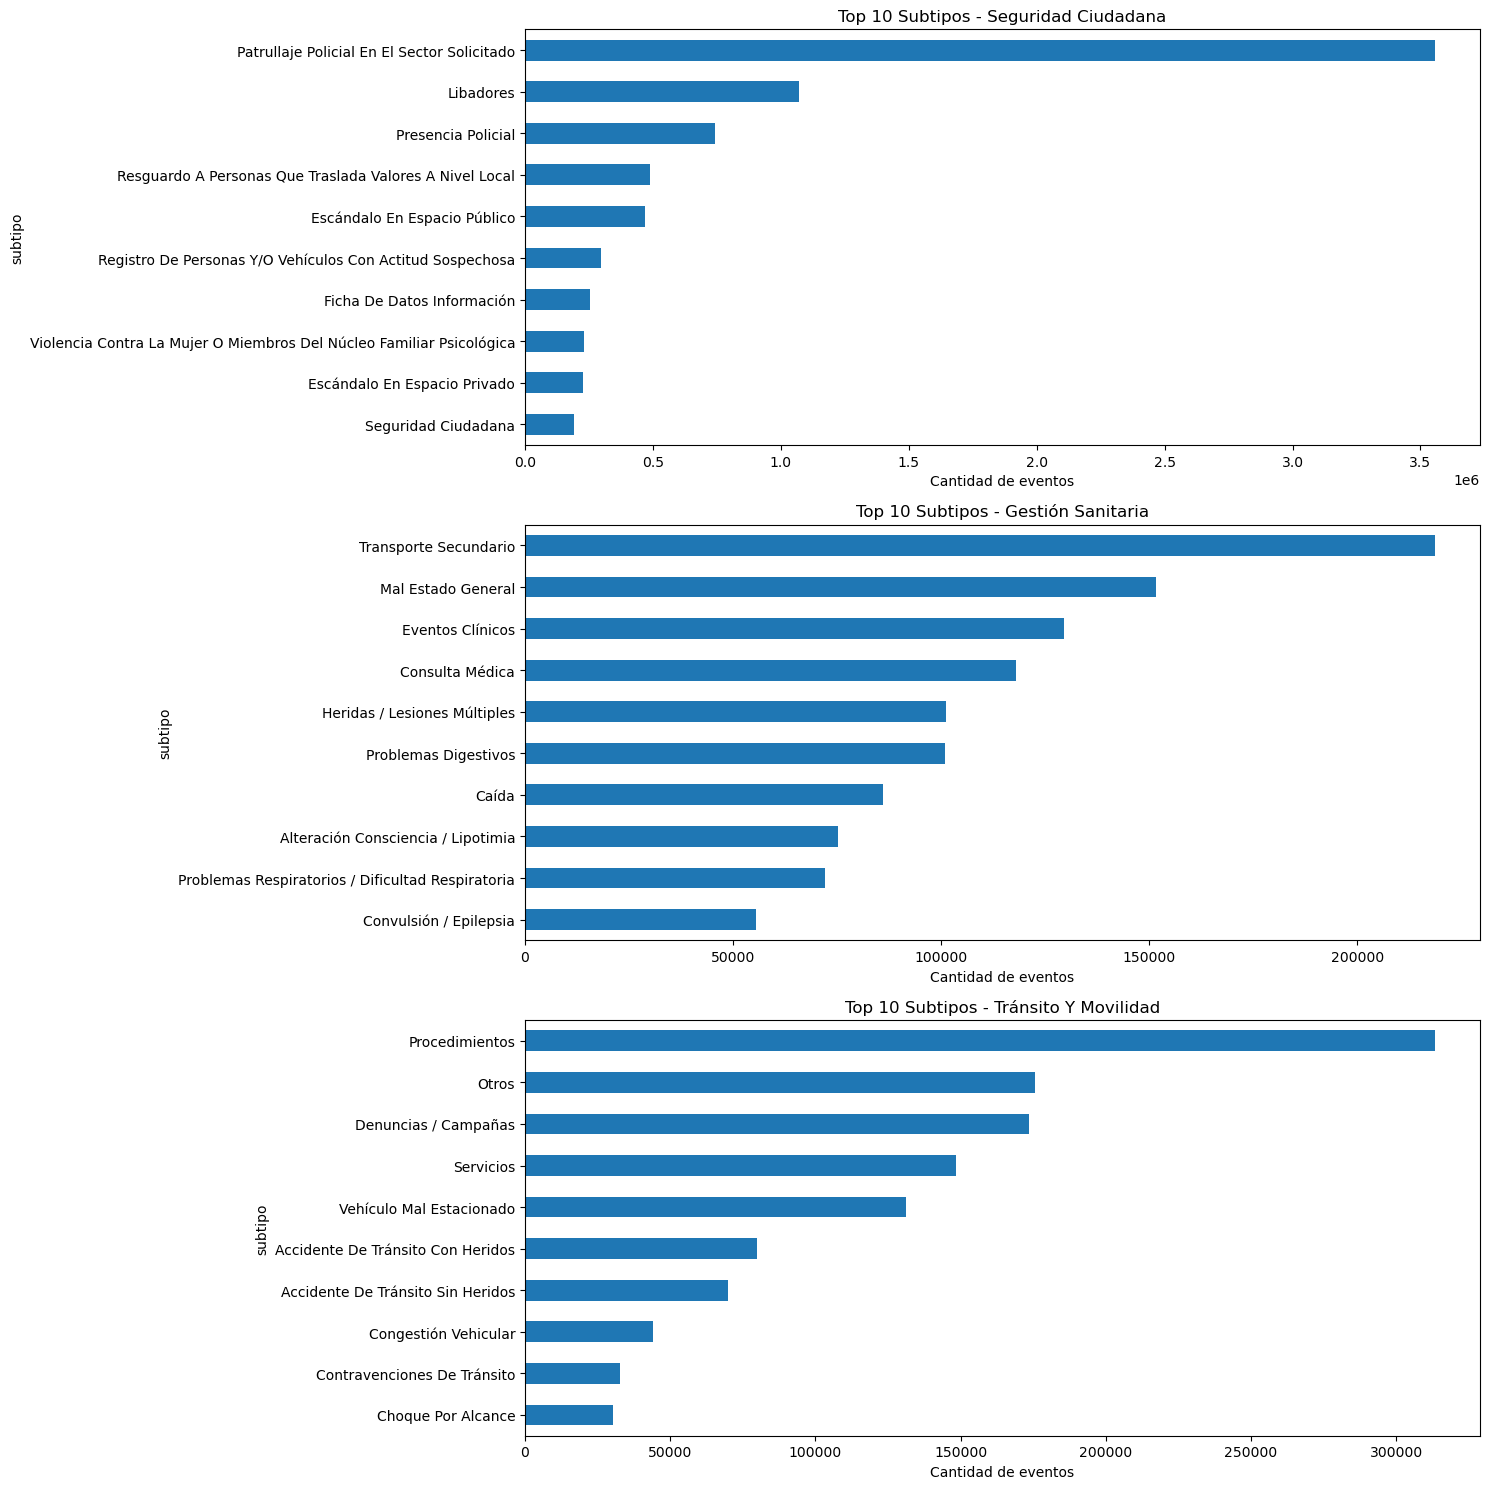

In [10]:
# Servicios principales
servicios_top = ['Seguridad Ciudadana', 'Gestión Sanitaria', 'Tránsito Y Movilidad']

# Crear figura con 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(15, 15), sharey=False)

for idx, servicio in enumerate(servicios_top):
    top_subtipos = (
        df[df["servicio"] == servicio]
        .groupby("subtipo")["cantidad_eventos"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )
    
    top_subtipos.plot(kind="barh", ax=axes[idx])
    axes[idx].set_title(f"Top 10 Subtipos - {servicio}")
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel("Cantidad de eventos")
    
plt.tight_layout()
plt.show()


/tmp/ipykernel_602/3616167801.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Blues', 10)
/tmp/ipykernel_602/3616167801.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Blues', 10)
/tmp/ipykernel_602/3616167801.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Blues', 10)


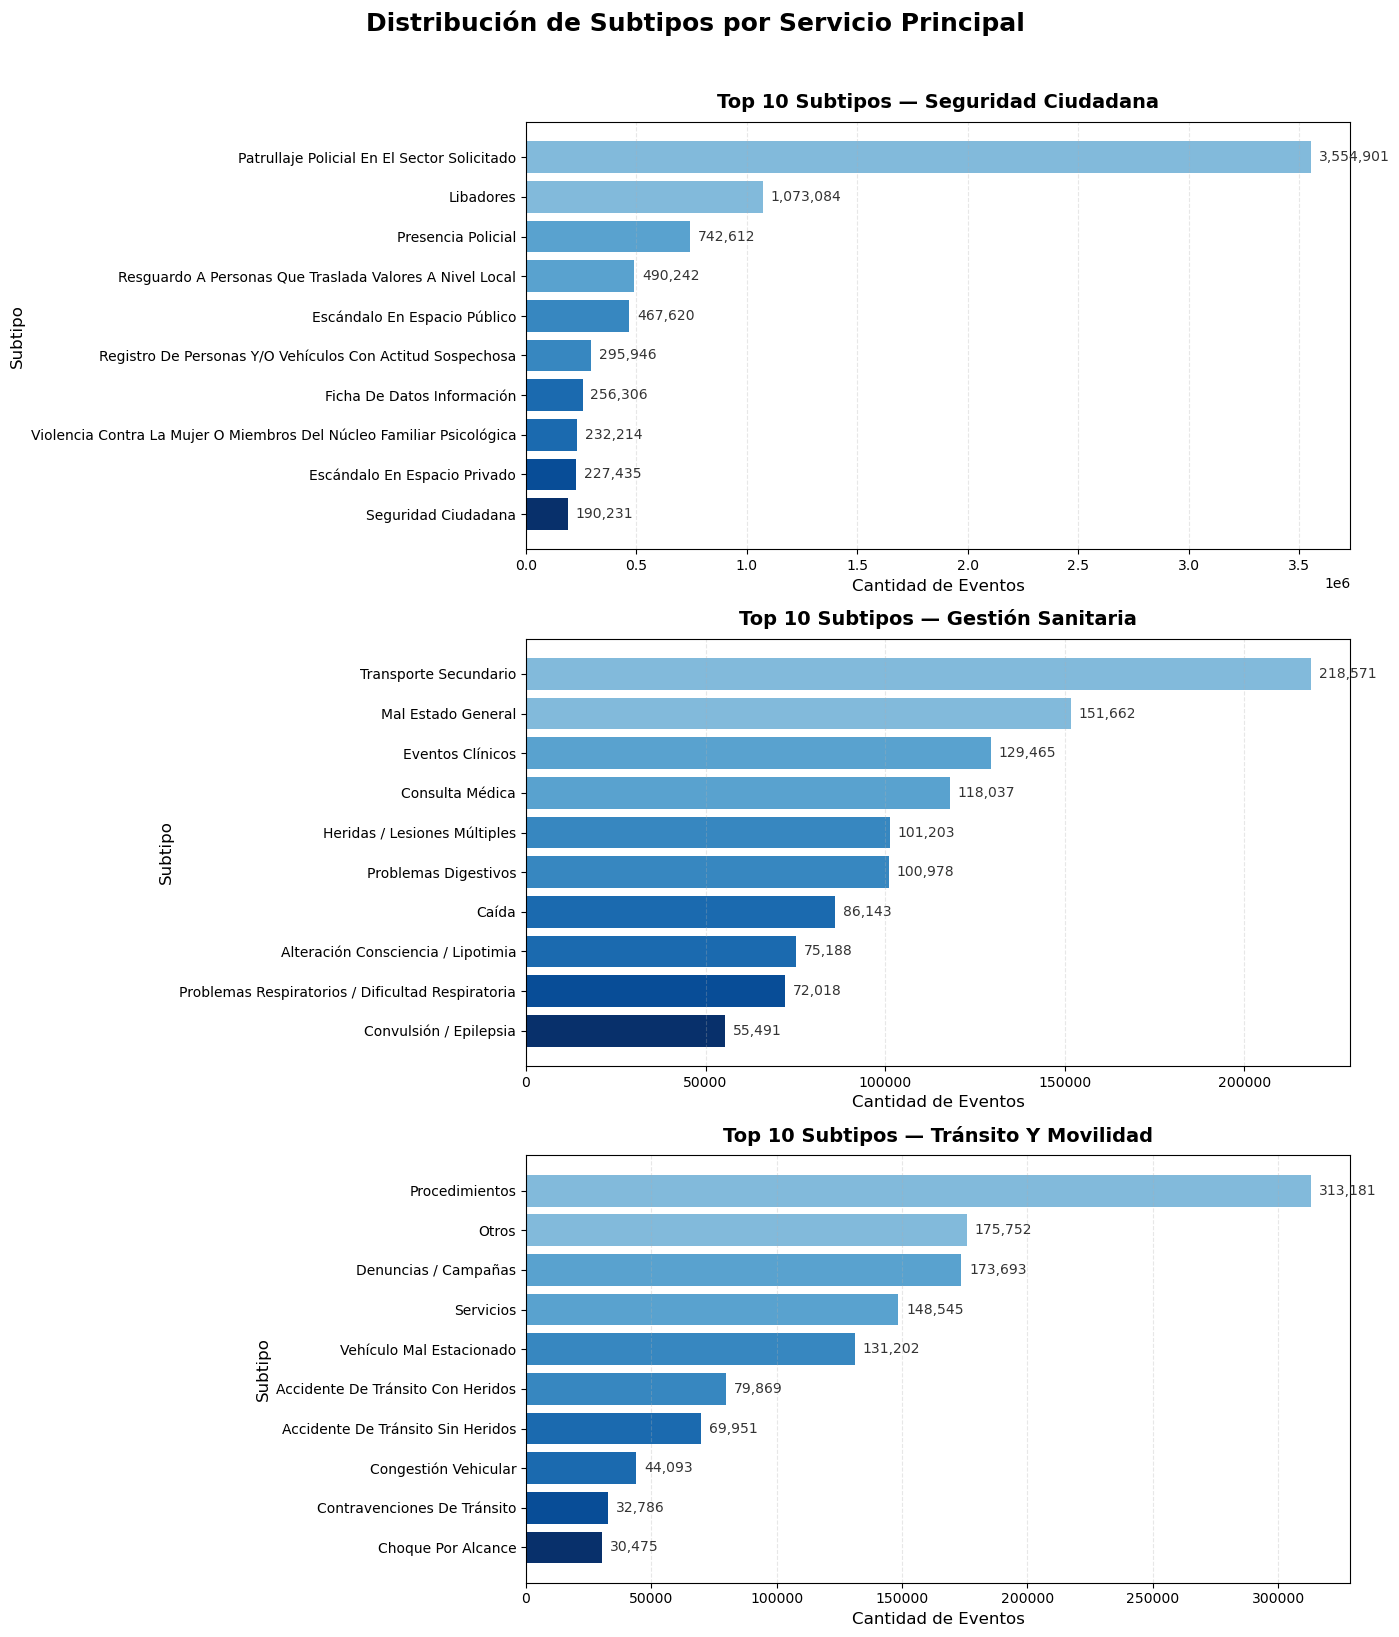

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Lista de servicios principales
servicios_top = ['Seguridad Ciudadana', 'Gestión Sanitaria', 'Tránsito Y Movilidad']

# Paleta de colores personalizada
colors = ['#4C72B0', '#55A868', '#C44E52']

# Crear figura
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

for idx, servicio in enumerate(servicios_top):
    top_subtipos = (
        df[df["servicio"] == servicio]
        .groupby("subtipo")["cantidad_eventos"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    # Colores degradados
    cmap = plt.cm.get_cmap('Blues', 10)
    bars = axes[idx].barh(top_subtipos.index, top_subtipos.values, color=cmap(np.linspace(0.4, 0.9, len(top_subtipos))))
    
    # Etiquetas numéricas
    for bar in bars:
        width = bar.get_width()
        axes[idx].text(width + max(top_subtipos.values)*0.01, bar.get_y() + bar.get_height()/2,
                       f'{int(width):,}', va='center', fontsize=10, color='#333')
    
    # Títulos y formato
    axes[idx].set_title(f'Top 10 Subtipos — {servicio}', fontsize=14, weight='bold', pad=10)
    axes[idx].set_xlabel('Cantidad de Eventos', fontsize=12)
    axes[idx].set_ylabel('Subtipo', fontsize=12)
    axes[idx].invert_yaxis()
    axes[idx].grid(axis='x', linestyle='--', alpha=0.3)

# Título general
fig.suptitle('Distribución de Subtipos por Servicio Principal', fontsize=18, weight='bold', y=1.02)

# Ajuste de diseño
plt.tight_layout()
plt.subplots_adjust(top=0.95)

# Guardar figura (opcional)
#plt.savefig('subtipos_por_servicio.png', dpi=300, bbox_inches='tight')
plt.savefig("../reports/fig/subtipos_por_servicio.png", bbox_inches="tight", transparent=False)

# Mostrar gráfico
plt.show()


/tmp/ipykernel_602/1157376663.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Oranges", len(provincias))


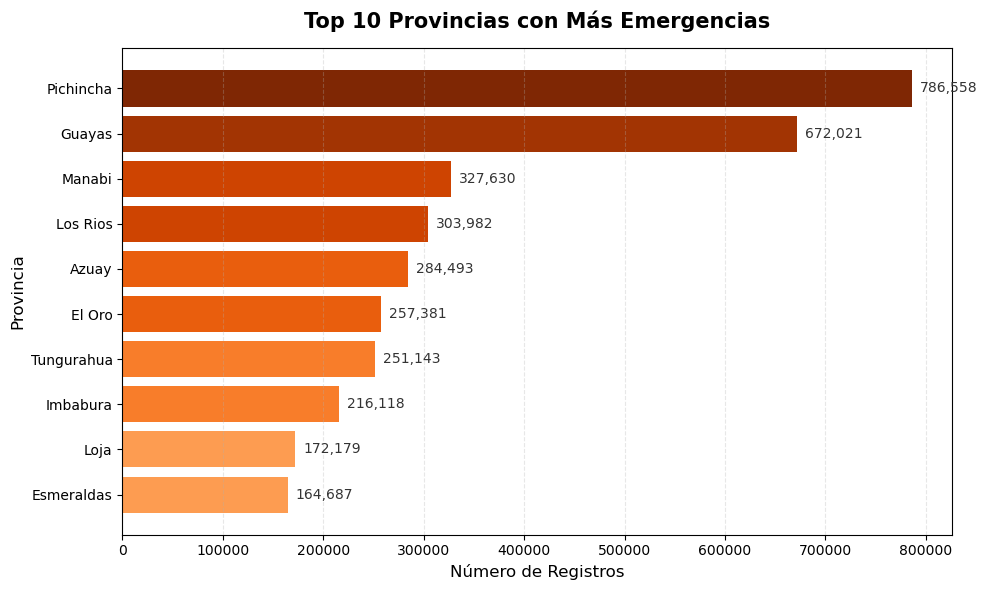

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Crear carpeta si no existe
os.makedirs("../reports/fig", exist_ok=True)

# Obtener top 10 provincias ordenadas
provincias = df["provincia"].value_counts().head(10).sort_values(ascending=True)

# Crear figura
plt.figure(figsize=(10,6))
cmap = plt.cm.get_cmap("Oranges", len(provincias))
bars = plt.barh(provincias.index, provincias.values, color=cmap(np.linspace(0.4, 0.9, len(provincias))))

# Etiquetas numéricas al final de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width + max(provincias.values)*0.01, bar.get_y() + bar.get_height()/2,
             f"{int(width):,}", va="center", fontsize=10, color="#333")

# Título y etiquetas
plt.title("Top 10 Provincias con Más Emergencias", fontsize=15, weight="bold", pad=15)
plt.xlabel("Número de Registros", fontsize=12)
plt.ylabel("Provincia", fontsize=12)

# Estilo visual
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()

# Guardar figura en tu estilo
plt.savefig("../reports/fig/top10_provincias.png", dpi=300, bbox_inches="tight", transparent=False)

# Mostrar gráfico
plt.show()


In [70]:
provincias

provincia
Esmeraldas    164687
Loja          172179
Imbabura      216118
Tungurahua    251143
El Oro        257381
Azuay         284493
Los Rios      303982
Manabi        327630
Guayas        672021
Pichincha     786558
Name: count, dtype: int64

In [17]:
# Función para clasificar por año móvil (jul-jun)
def asignar_periodo_movil(fecha):
    if fecha >= pd.Timestamp("2021-07-01") and fecha <= pd.Timestamp("2022-06-30"):
        return "2021–2022"
    elif fecha >= pd.Timestamp("2022-07-01") and fecha <= pd.Timestamp("2023-06-30"):
        return "2022–2023"
    elif fecha >= pd.Timestamp("2023-07-01") and fecha <= pd.Timestamp("2024-06-30"):
        return "2023–2024"
    elif fecha >= pd.Timestamp("2024-07-01") and fecha <= pd.Timestamp("2025-08-31"):
        return "2024–2025"
    else:
        return None  # fuera de rango


In [18]:
df.head()

,fecha,provincia,canton,cod_parroquia,parroquia,servicio,subtipo,cantidad_eventos
0,2022-04-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Gestión Sanitaria,Problemas En El Embarazo,1
1,2022-04-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Seguridad Ciudadana,Patrullaje Policial En El Sector Solicitado,1
2,2022-04-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Seguridad Ciudadana,Resguardo A Personas Que Traslada Valores A Ni...,1
3,2022-04-01,Azuay,Chordeleg,11150,"Chordeleg, Cabecera Cantonal",Seguridad Ciudadana,Patrullaje Policial En El Sector Solicitado,1
4,2022-04-01,Azuay,Cuenca,10150,"Cuenca, Cabecera Cantonal Y Capital Provincial.",Gestión De Riesgos,Amenazas Naturales,1


In [19]:
df['periodo'] = df['fecha'].apply(asignar_periodo_movil)

In [20]:
df[df['fecha'] == pd.Timestamp('2025-08-01')].head()

,fecha,provincia,canton,cod_parroquia,parroquia,servicio,subtipo,cantidad_eventos,periodo
3215372,2025-08-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Seguridad Ciudadana,Escándalo En Espacio Privado,1,2024–2025
3215373,2025-08-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Seguridad Ciudadana,Libadores,1,2024–2025
3215374,2025-08-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Seguridad Ciudadana,Patrullaje Policial En El Sector Solicitado,2,2024–2025
3215375,2025-08-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Seguridad Ciudadana,Violencia Contra La Mujer O Miembros Del Núcle...,1,2024–2025
3215376,2025-08-01,Azuay,Chordeleg,11150,"Chordeleg, Cabecera Cantonal",Seguridad Ciudadana,Abigeato,1,2024–2025


In [21]:
df_prov_periodo = df.groupby(['provincia', 'periodo'])['cantidad_eventos'].sum().reset_index()


In [22]:
df_prov_periodo.head()

,provincia,periodo,cantidad_eventos
0,Azuay,2021–2022,201681
1,Azuay,2022–2023,202749
2,Azuay,2023–2024,176872
3,Azuay,2024–2025,205447
4,Bolivar,2021–2022,42126


In [23]:
import geopandas as gpd

gdf = gpd.read_file("../data/ecuador.geojson")

# Revisar columnas disponibles
print(gdf.columns)


Index(['DPA_VALOR', 'DPA_ANIO', 'DPA_CANTON', 'DPA_DESCAN', 'DPA_PROVIN',
       'DPA_DESPRO', 'PCODE2', 'geometry'],
      dtype='object')


In [24]:
# Normaliza nombre de provincia (como está en tu DataFrame de emergencias)
gdf['provincia'] = gdf['DPA_DESPRO'].str.title().str.strip()


In [25]:
gdf_provincias = gdf.dissolve(by='provincia', as_index=False)

In [26]:
gdf_provincias.head()

,provincia,geometry,DPA_VALOR,DPA_ANIO,DPA_CANTON,DPA_DESCAN,DPA_PROVIN,DPA_DESPRO,PCODE2
0,Azuay,"POLYGON ((-79.04407 -3.48116, -79.04632 -3.486...",0,2011,0101,CUENCA,01,AZUAY,EC0101
1,Bolivar,"POLYGON ((-79.01276 -1.88005, -79.01488 -1.888...",0,2011,0201,GUARANDA,02,BOLIVAR,EC0201
2,Carchi,"POLYGON ((-77.80728 0.4142, -77.81167 0.41004,...",0,2011,0401,TULCAN,04,CARCHI,EC0401
3,Caðar,"POLYGON ((-78.94447 -2.82907, -78.94809 -2.819...",0,2011,0301,AZOGUES,03,CAÐAR,EC0301
4,Chimborazo,"POLYGON ((-78.83311 -2.38419, -78.84554 -2.397...",0,2011,0601,RIOBAMBA,06,CHIMBORAZO,EC0601


/tmp/ipykernel_602/3106334943.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar


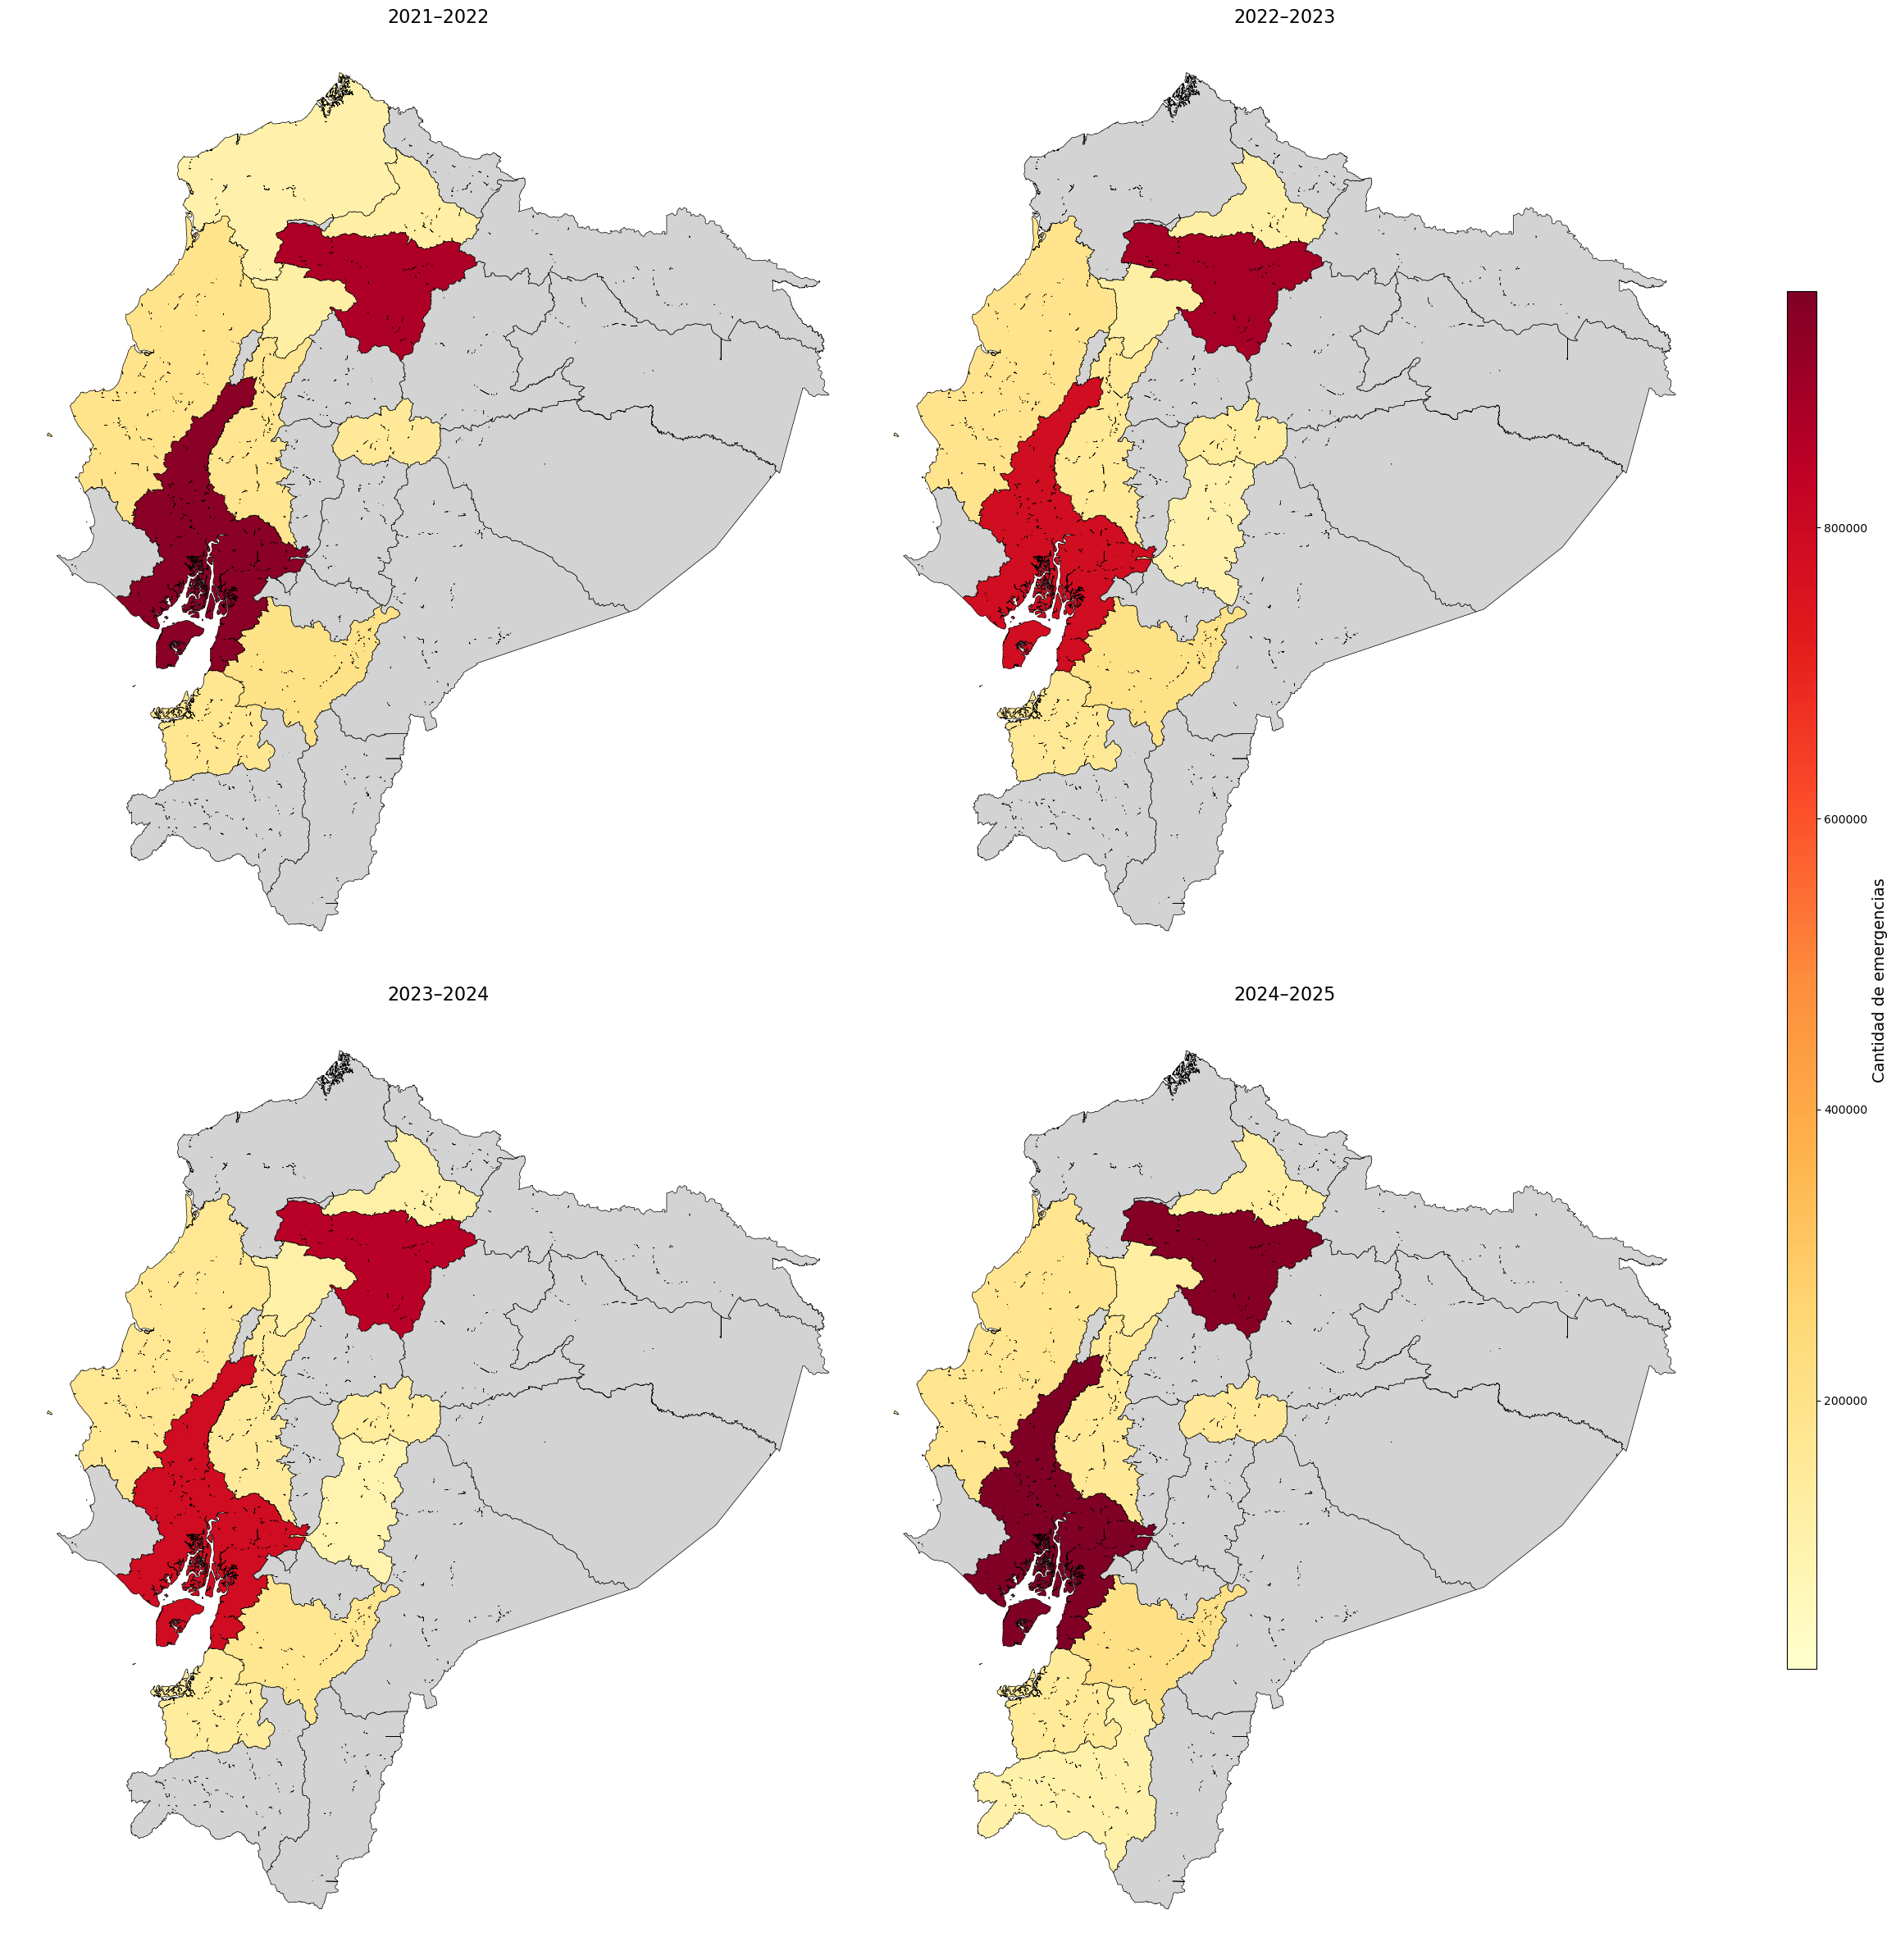

In [35]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
periodos = ['2021–2022', '2022–2023', '2023–2024', '2024–2025']

# Exclude Galápagos
gdf_filtered = gdf_provincias[~gdf_provincias['provincia'].str.upper().str.contains("GALAPAGOS")]
df_filtered = df_prov_periodo[~df_prov_periodo['provincia'].str.upper().str.contains("GALAPAGOS")]

# Define consistent color scale
vmin = df_filtered['cantidad_eventos'].min()
vmax = df_filtered['cantidad_eventos'].max()
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.YlOrRd

# Set up subplots
fig, axes = plt.subplots(2, 2, figsize=(24, 24))
axes = axes.flatten()

# Plot each period
for i, periodo in enumerate(periodos):
    top10 = df_filtered[df_filtered['periodo'] == periodo].nlargest(10, 'cantidad_eventos')
    gdf_merge = gdf_filtered.merge(top10, on='provincia', how='left')
    
    gdf_merge.plot(column='cantidad_eventos', cmap=cmap, norm=norm, linewidth=0.5,
                   ax=axes[i], edgecolor='black', legend=False,
                   missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'})
    
    axes[i].set_title(f"{periodo}", fontsize=16)
    axes[i].axis('off')

# Add shared colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []  # required for matplotlib < 3.1

cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Cantidad de emergencias', fontsize=14)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar
plt.savefig("../reports/fig/top10_mapa_incidencias.png", bbox_inches="tight", transparent=False)
plt.show()



In [39]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# Cargar población
df_pob = pd.read_csv("../data/poblacion_provincias_ecuador_2022.csv")

# Unir con datos de emergencias
df_filtered = df_prov_periodo.merge(df_pob, on="provincia", how="left")

# Calcular emergencias por 100 mil habitantes
df_filtered["emergencias_per_100k"] = df_filtered["cantidad_eventos"] / df_filtered["poblacion_2022"] * 100_000

In [40]:
df_filtered.head()

,provincia,periodo,cantidad_eventos,poblacion_2022,emergencias_per_100k
0,Azuay,2021–2022,201681,801609.0,25159.522910
1,Azuay,2022–2023,202749,801609.0,25292.754947
2,Azuay,2023–2024,176872,801609.0,22064.622528
3,Azuay,2024–2025,205447,801609.0,25629.328014
4,Bolivar,2021–2022,42126,199078.0,21160.550136


/tmp/ipykernel_602/1866423628.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


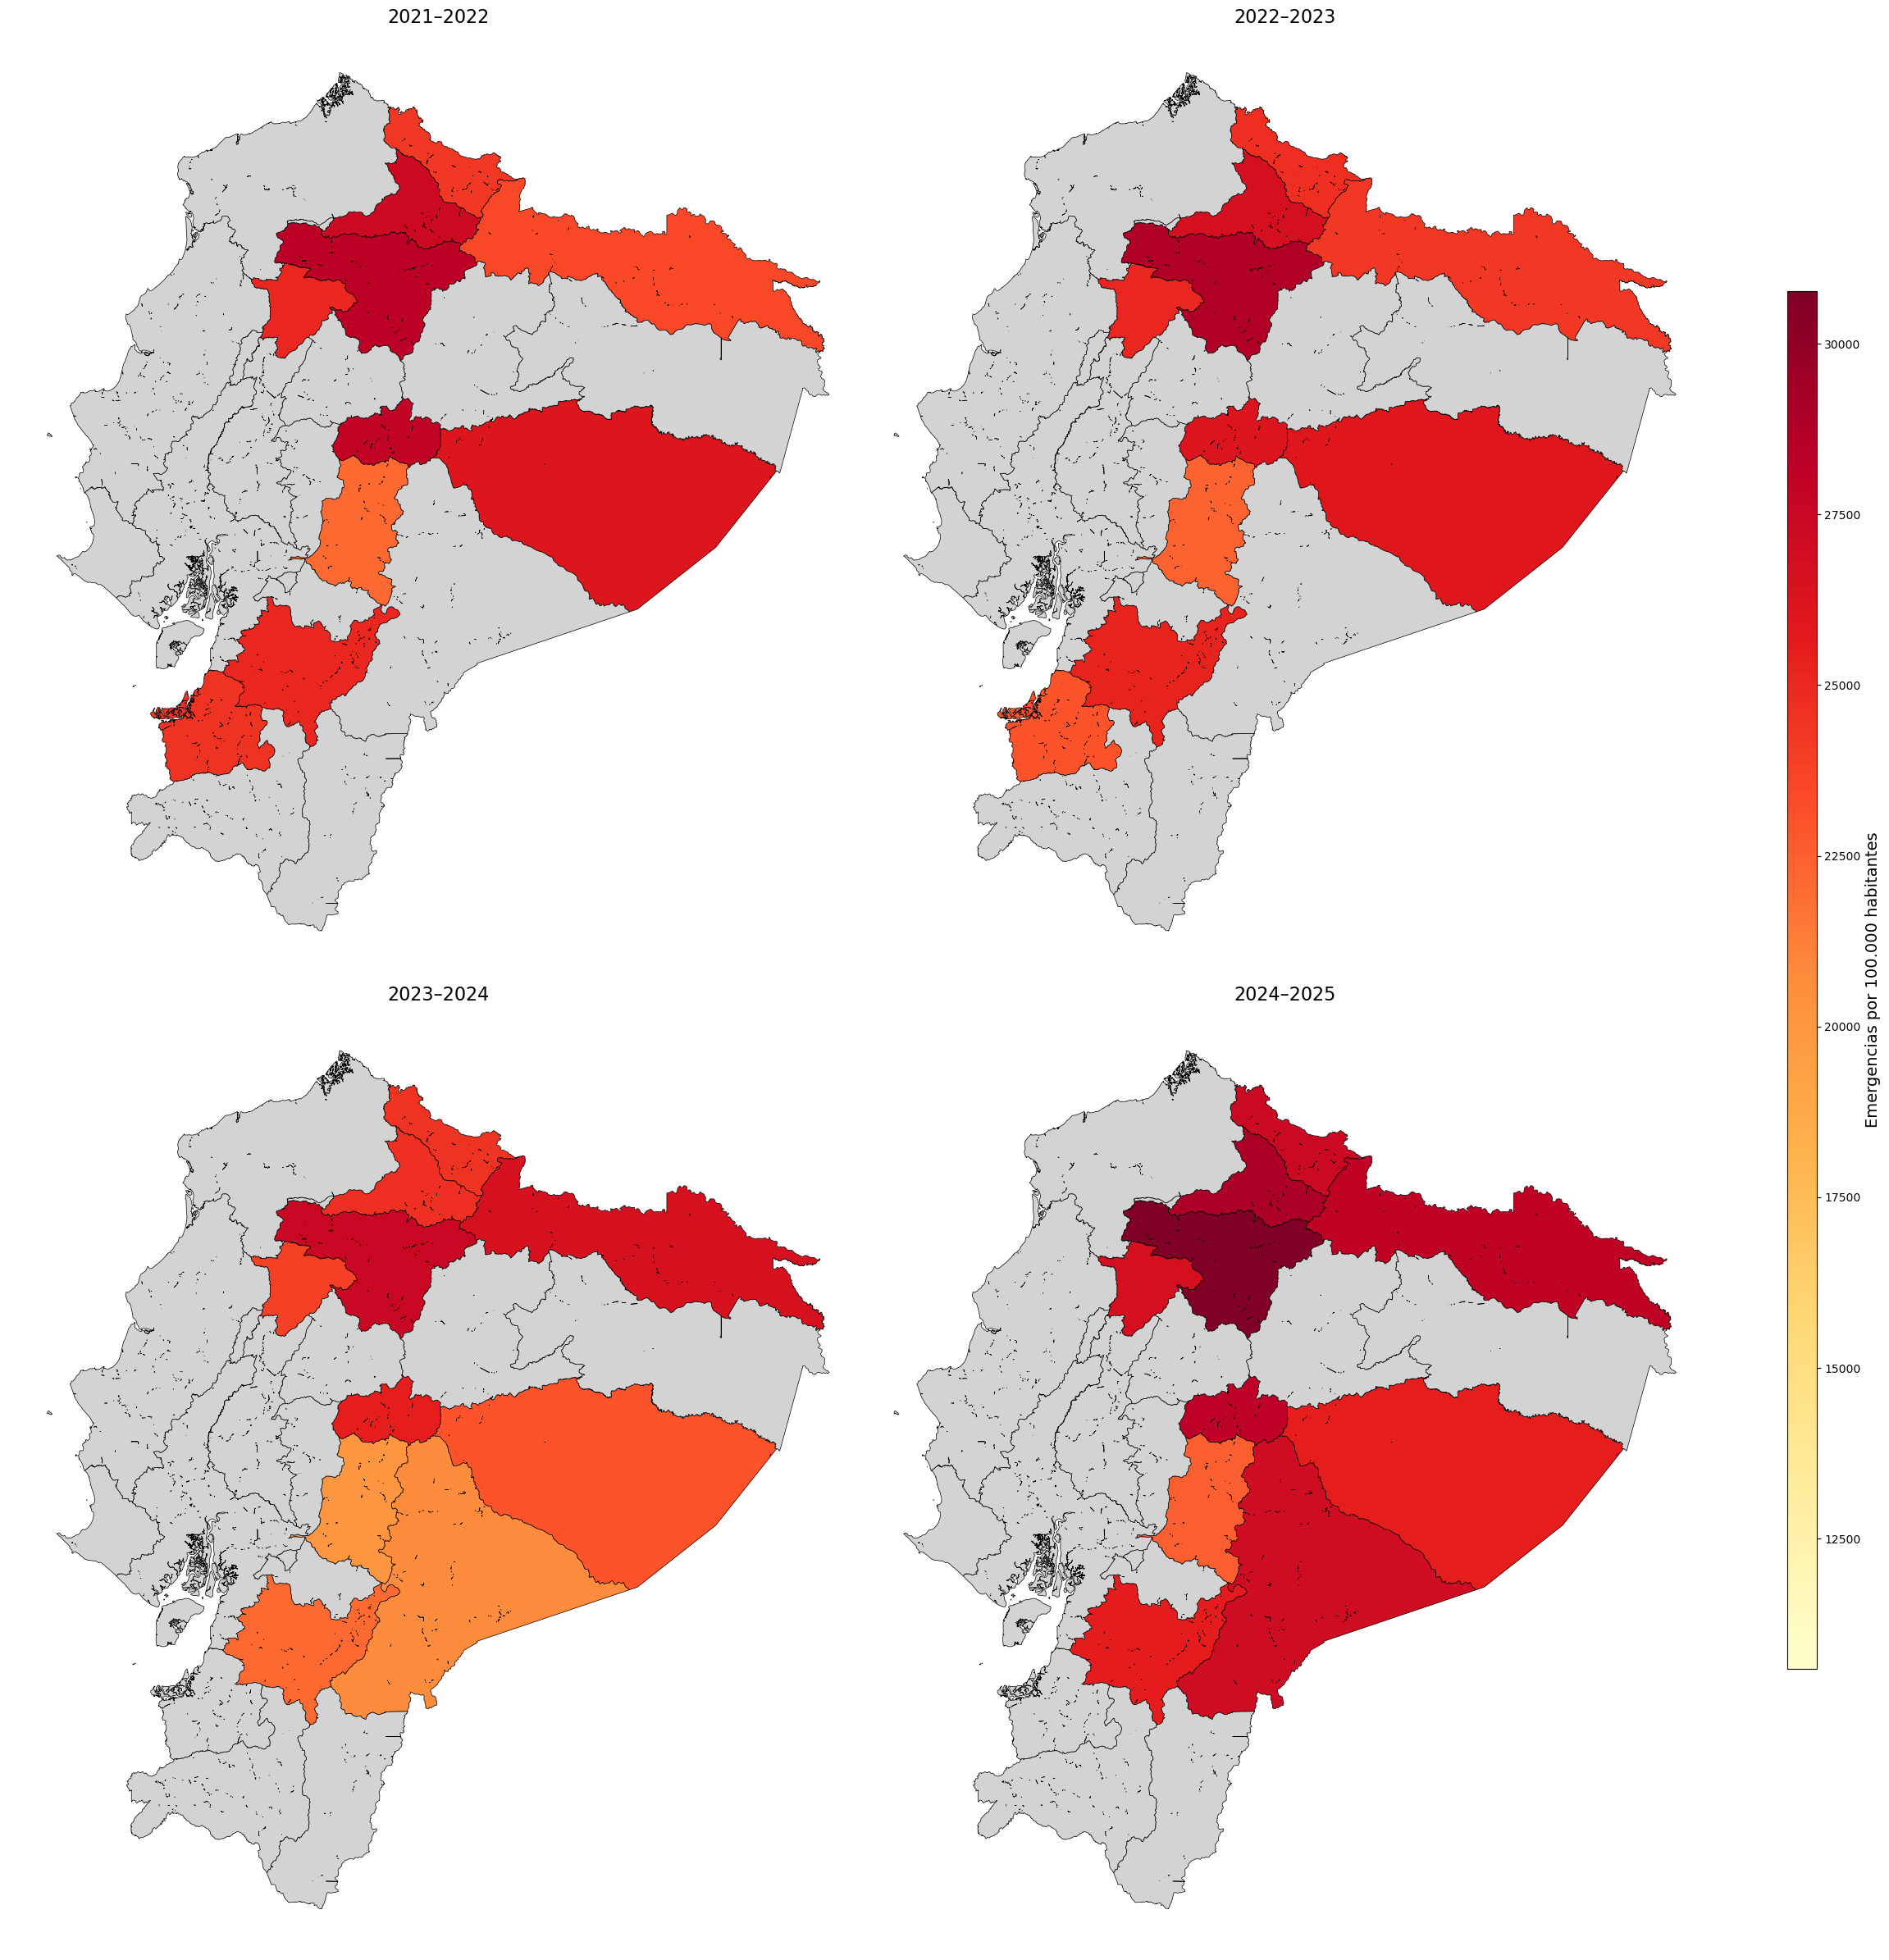

In [41]:


# Excluir Galápagos si lo deseas
df_filtered = df_filtered[~df_filtered['provincia'].str.upper().str.contains("GALAPAGOS")]
gdf_filtered = gdf_provincias[~gdf_provincias['provincia'].str.upper().str.contains("GALAPAGOS")]

# Escala común
vmin = df_filtered["emergencias_per_100k"].min()
vmax = df_filtered["emergencias_per_100k"].max()
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.YlOrRd

# Plot
fig, axes = plt.subplots(2, 2, figsize=(24, 24))
axes = axes.flatten()

for i, periodo in enumerate(periodos):
    top10 = df_filtered[df_filtered['periodo'] == periodo].nlargest(10, 'emergencias_per_100k')
    gdf_merge = gdf_filtered.merge(top10, on='provincia', how='left')
    
    gdf_merge.plot(column='emergencias_per_100k', cmap=cmap, norm=norm, linewidth=0.5,
                   ax=axes[i], edgecolor='black', legend=False,
                   missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'})
    
    axes[i].set_title(f"{periodo}", fontsize=16)
    axes[i].axis('off')

# Colorbar única
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Emergencias por 100.000 habitantes', fontsize=14)

plt.savefig("../reports/fig/top10_mapa_percapita.png",bbox_inches="tight", transparent=False)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

In [42]:
df.head()

,fecha,provincia,canton,cod_parroquia,parroquia,servicio,subtipo,cantidad_eventos,periodo
0,2022-04-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Gestión Sanitaria,Problemas En El Embarazo,1,2021–2022
1,2022-04-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Seguridad Ciudadana,Patrullaje Policial En El Sector Solicitado,1,2021–2022
2,2022-04-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Seguridad Ciudadana,Resguardo A Personas Que Traslada Valores A Ni...,1,2021–2022
3,2022-04-01,Azuay,Chordeleg,11150,"Chordeleg, Cabecera Cantonal",Seguridad Ciudadana,Patrullaje Policial En El Sector Solicitado,1,2021–2022
4,2022-04-01,Azuay,Cuenca,10150,"Cuenca, Cabecera Cantonal Y Capital Provincial.",Gestión De Riesgos,Amenazas Naturales,1,2021–2022


### Evolucion anual del Promedio de registros por dia y por provincia 

In [43]:
df_diario = (
    df.groupby(['provincia', 'periodo', 'fecha'])['cantidad_eventos']
      .sum()
      .reset_index()
)

# Calcular promedio diario por provincia y periodo
# Calcular media y desviación estándar diaria por provincia y periodo
df_stats = (
    df_diario.groupby(['provincia', 'periodo'])['cantidad_eventos']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'promedio_diario', 'std': 'desviacion'})
)

df_stats_pivot = df_stats.pivot(index='provincia', columns='periodo', values='promedio_diario')
df_std_pivot = df_stats.pivot(index='provincia', columns='periodo', values='desviacion')

# Ordenar provincias alfabéticamente
df_stats_pivot = df_stats_pivot.sort_index()
df_std_pivot = df_std_pivot.sort_index()


In [44]:
df_summary = df_stats_pivot.add_suffix('_promedio').join(
    df_std_pivot.add_suffix('_std')
)
df_summary.head()

# (Opcional) Exportar a CSV
#df_pivot.to_csv("promedio_diario_emergencias_por_provincia.csv")


periodo,2021–2022_promedio,2022–2023_promedio,2023–2024_promedio,2024–2025_promedio,2021–2022_std,2022–2023_std,2023–2024_std,2024–2025_std
provincia,,,,,,,,
Azuay,557.129834,555.476712,483.256831,481.140515,137.532075,103.732870,116.654599,88.642283
Bolivar,115.413699,82.205479,98.366120,101.906323,26.409837,26.796424,23.197127,21.307290
Carchi,115.060274,117.156164,115.636612,110.644028,26.951660,25.393502,27.399763,24.123114
Cañar,109.859116,103.298630,91.795082,85.152225,28.956449,22.245289,22.934190,20.953397
Chimborazo,285.084932,289.504110,259.275956,249.327869,56.968238,44.885362,47.415307,37.082198


In [45]:
df_summary

periodo,2021–2022_promedio,2022–2023_promedio,2023–2024_promedio,2024–2025_promedio,2021–2022_std,2022–2023_std,2023–2024_std,2024–2025_std
provincia,,,,,,,,
Azuay,557.129834,555.476712,483.256831,481.140515,137.532075,103.732870,116.654599,88.642283
Bolivar,115.413699,82.205479,98.366120,101.906323,26.409837,26.796424,23.197127,21.307290
Carchi,115.060274,117.156164,115.636612,110.644028,26.951660,25.393502,27.399763,24.123114
Cañar,109.859116,103.298630,91.795082,85.152225,28.956449,22.245289,22.934190,20.953397
Chimborazo,285.084932,289.504110,259.275956,249.327869,56.968238,44.885362,47.415307,37.082198
Cotopaxi,195.882192,201.991781,194.366120,210.843091,42.023539,41.146781,38.978425,36.043352
El Oro,478.989041,450.506849,392.232240,363.887588,120.319834,89.710328,83.969943,69.594611
Esmeraldas,292.608219,225.284932,173.046448,174.922717,72.799230,52.811461,41.853829,46.008227
Galapagos,30.128767,31.745205,28.556164,26.435597,7.668787,7.655226,7.397300,7.428371


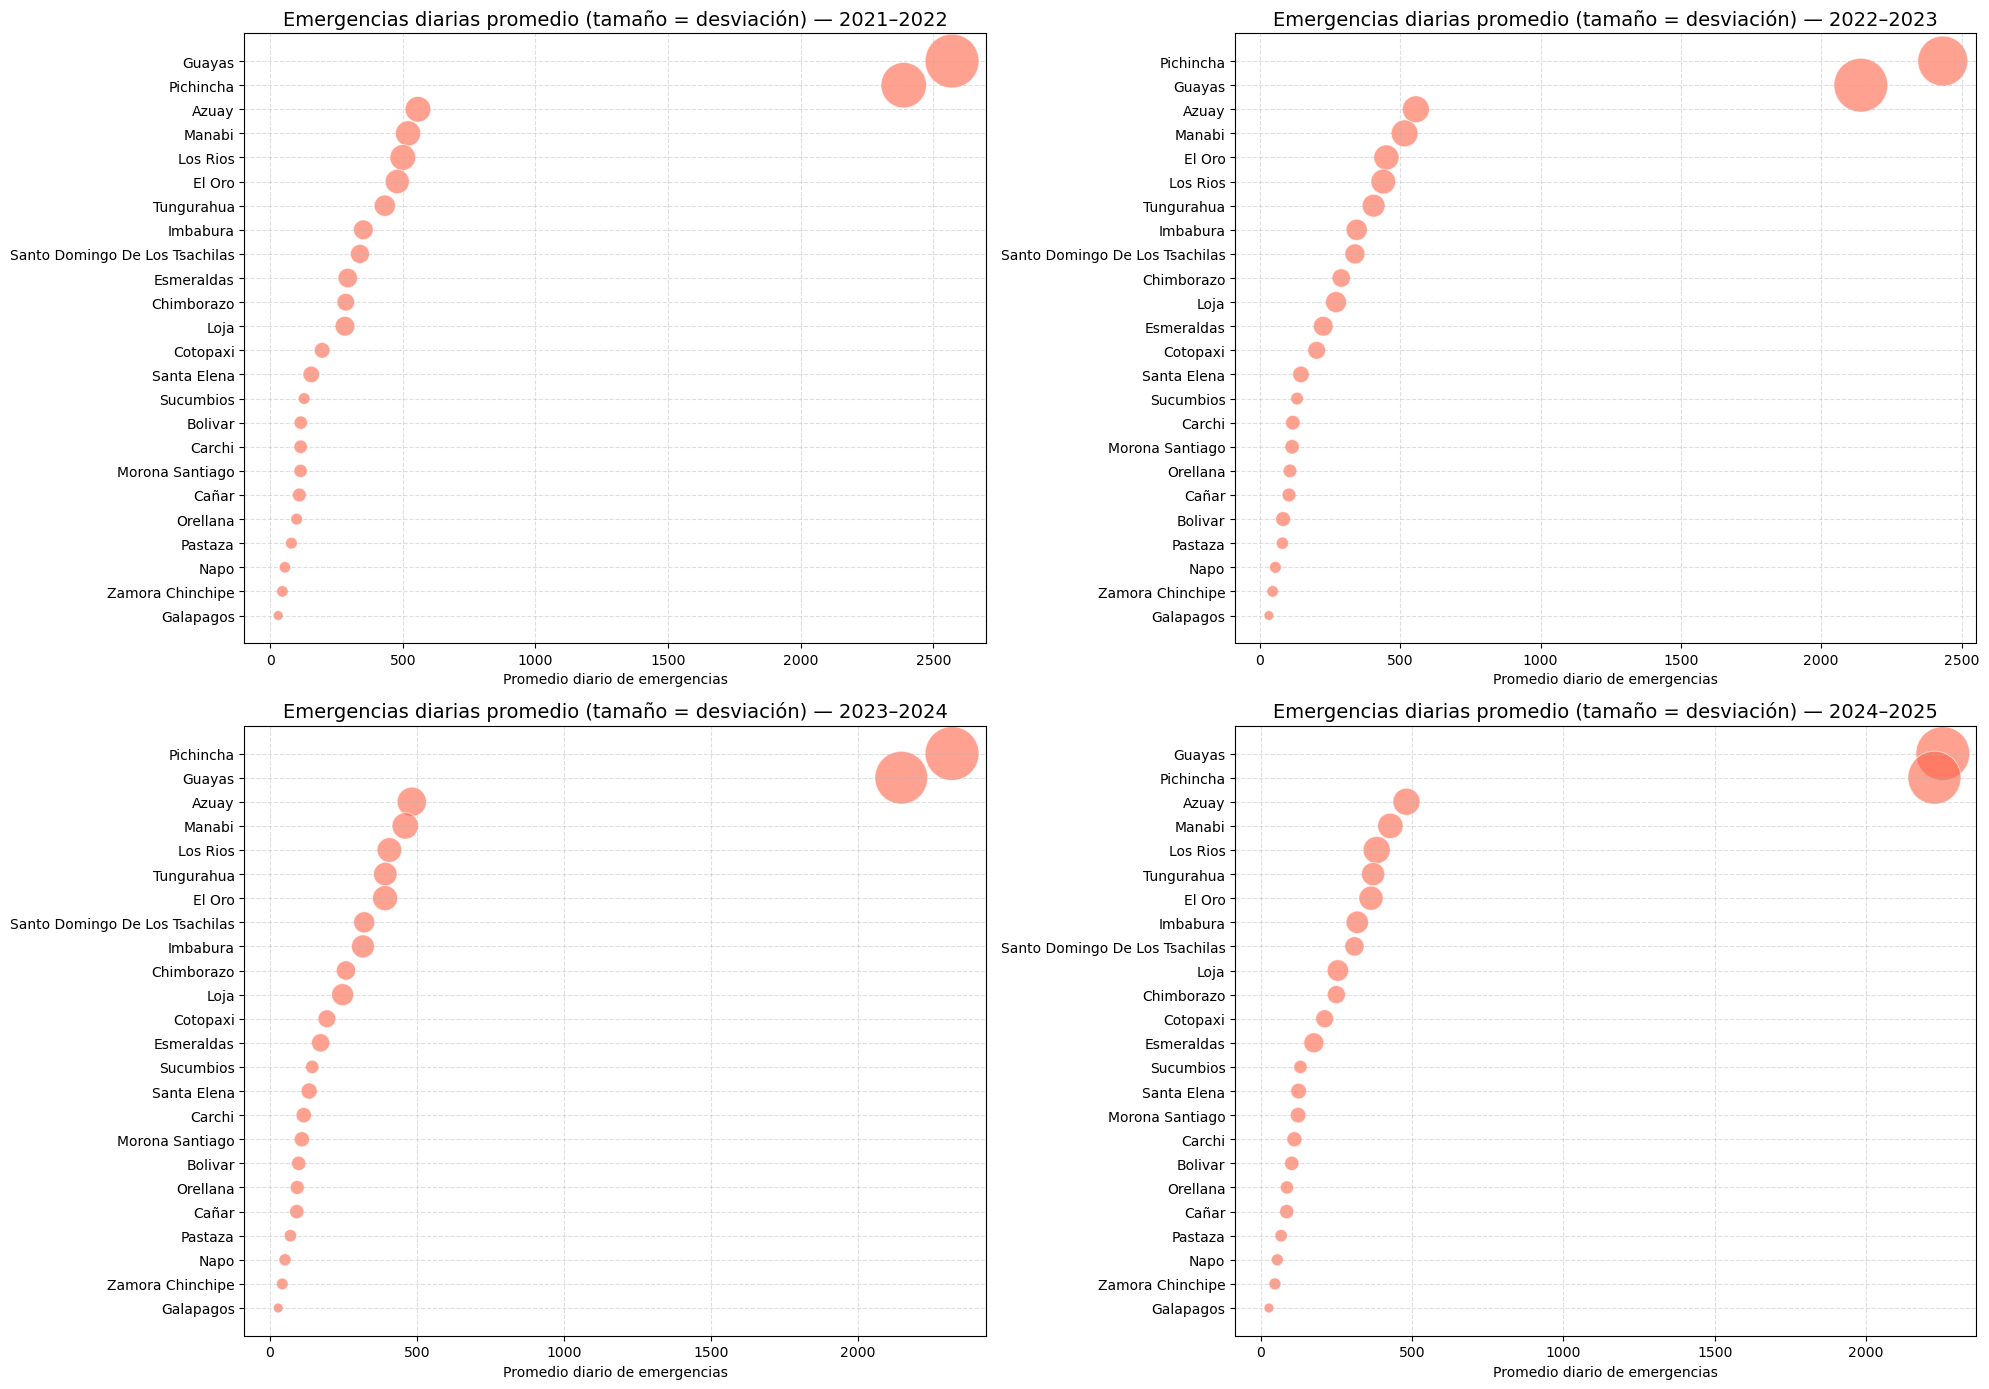

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Normalizar tamaño de burbujas para visualización
def scale_size(x, min_size=50, max_size=1500):
    return min_size + (x - x.min()) / (x.max() - x.min()) * (max_size - min_size)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for i, periodo in enumerate(periodos):
    subset = df_stats[df_stats['periodo'] == periodo]
    subset = subset.sort_values('promedio_diario', ascending=False)

    # Escalar tamaño de burbujas
    sizes = scale_size(subset['desviacion'])
    
    sns.scatterplot(
        data=subset,
        x='promedio_diario', y='provincia',
        size=sizes, sizes=(50, 1500),
        alpha=0.6, color='tomato', ax=axes[i], legend=False
    )
    
    axes[i].set_title(f"Emergencias diarias promedio (tamaño = desviación) — {periodo}", fontsize=14)
    axes[i].set_xlabel("Promedio diario de emergencias")
    axes[i].set_ylabel("")
    axes[i].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Función para escalar tamaño de burbujas
def scale_size(x, min_size=50, max_size=1500):
    return min_size + (x - x.min()) / (x.max() - x.min()) * (max_size - min_size)

# Provincias a excluir
excluir = ['Guayas', 'Pichincha']

# Crear subplots
periodos = ['2021–2022', '2022–2023', '2023–2024', '2024–2025']
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for i, periodo in enumerate(periodos):
    subset = df_stats[
        (df_stats['periodo'] == periodo) &
        (~df_stats['provincia'].isin(excluir))
    ].copy()
    
    subset = subset.sort_values('promedio_diario', ascending=False)
    sizes = scale_size(subset['desviacion'])
    
    sns.scatterplot(
        data=subset,
        x='promedio_diario', y='provincia',
        size=sizes, sizes=(50, 1500),
        alpha=0.6, color='steelblue', ax=axes[i], legend=False
    )
    
    axes[i].set_title(f"Emergencias diarias promedio (sin Guayas y Pichincha) — {periodo}", fontsize=14)
    axes[i].set_xlabel("Promedio diario de emergencias")
    axes[i].set_ylabel("")
    axes[i].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


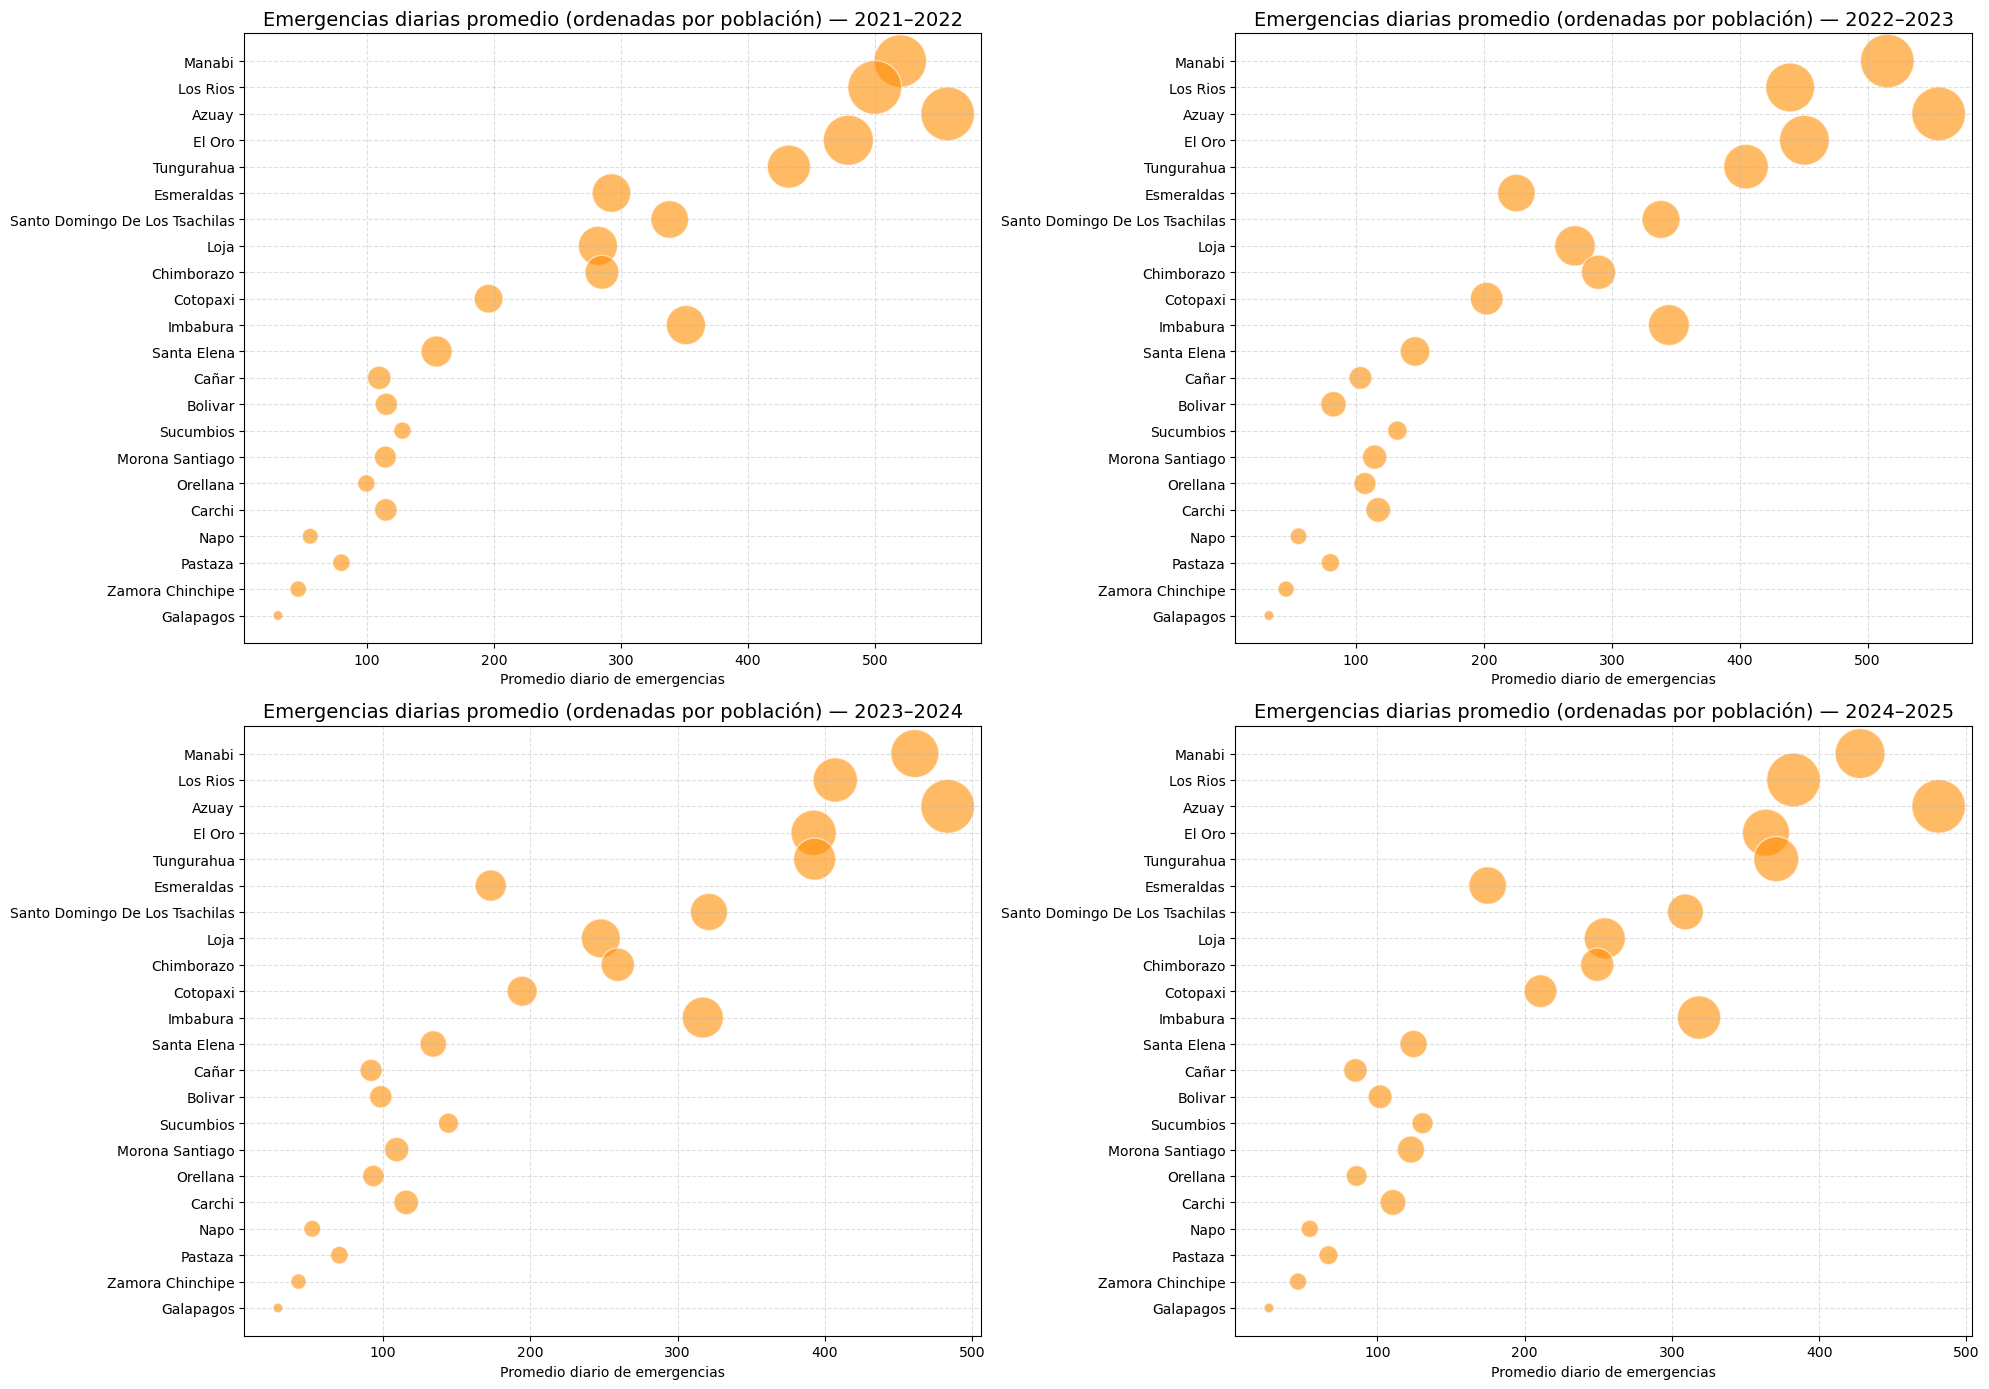

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Escalar tamaño de burbujas
def scale_size(x, min_size=50, max_size=1500):
    return min_size + (x - x.min()) / (x.max() - x.min()) * (max_size - min_size)

# Provincias a excluir (outliers)
excluir = ['Guayas', 'Pichincha']

# Merge con datos de población
df_stats_pob = df_stats.merge(df_pob, on='provincia', how='left')

# Crear subplots
periodos = ['2021–2022', '2022–2023', '2023–2024', '2024–2025']
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for i, periodo in enumerate(periodos):
    subset = df_stats_pob[
        (df_stats_pob['periodo'] == periodo) &
        (~df_stats_pob['provincia'].isin(excluir))
    ].copy()

    # Ordenar por población (descendente)
    subset = subset.sort_values('poblacion_2022', ascending=False)
    sizes = scale_size(subset['desviacion'])
    
    sns.scatterplot(
        data=subset,
        x='promedio_diario',
        y='provincia',
        size=sizes, sizes=(50, 1500),
        alpha=0.6, color='darkorange',
        ax=axes[i], legend=False
    )
    
    axes[i].set_title(f"Emergencias diarias promedio (ordenadas por población) — {periodo}", fontsize=14)
    axes[i].set_xlabel("Promedio diario de emergencias")
    axes[i].set_ylabel("")
    axes[i].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../reports/fig/bubble_incidencias_tamaño.png", bbox_inches="tight", transparent=False)
plt.show()


### Efecto de los feriados y fines de semana

In [49]:
df['dia_semana'] = df['fecha'].dt.dayofweek  # 0 = lunes, 6 = domingo

# Sumar emergencias por día y día_semana
df_semana = (
    df.groupby(['dia_semana', 'fecha'])['cantidad_eventos']
      .sum()
      .reset_index()
)

# Calcular promedio por día de la semana
df_prom_semana = df_semana.groupby('dia_semana')['cantidad_eventos'].mean().reset_index()
df_prom_semana['nombre_dia'] = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

In [50]:
df_prom_semana.head()

,dia_semana,cantidad_eventos,nombre_dia
0,0,8629.838710,Lunes
1,1,8033.539171,Martes
2,2,8275.147465,Miércoles
3,3,8573.834862,Jueves
4,4,9769.220183,Viernes


/tmp/ipykernel_602/1413809451.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


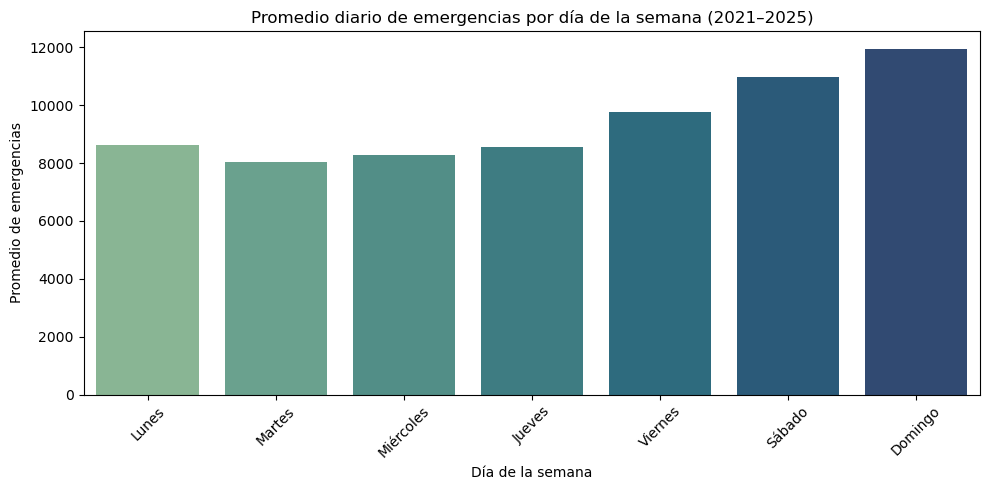

In [52]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df_prom_semana,
    x='nombre_dia', y='cantidad_eventos',
    palette='crest'
)
plt.title("Promedio diario de emergencias por día de la semana (2021–2025)")
plt.xlabel("Día de la semana")
plt.ylabel("Promedio de emergencias")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/fig/emergencias_dia.png", bbox_inches="tight", transparent=False)
plt.show()


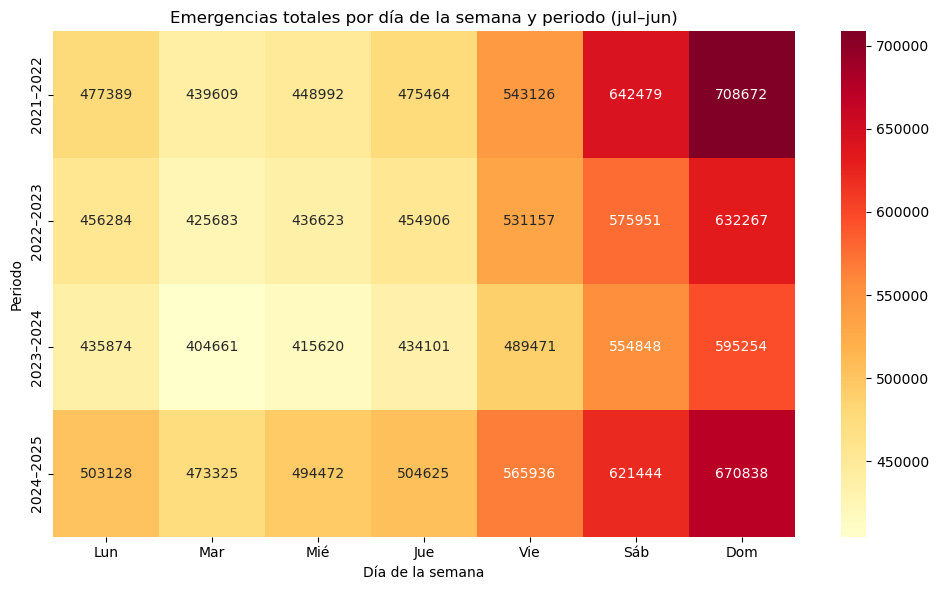

In [54]:

df_heat = (
    df.groupby(['periodo', 'dia_semana'])['cantidad_eventos']
      .sum()
      .reset_index()
)

# Pivot para heatmap
heatmap_data = df_heat.pivot(index='periodo', columns='dia_semana', values='cantidad_eventos')
heatmap_data.columns = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt=".0f")
plt.title("Emergencias totales por día de la semana y periodo (jul–jun)")
plt.xlabel("Día de la semana")
plt.ylabel("Periodo")
plt.tight_layout()
plt.savefig("../reports/fig/heat_emergencias_dia.png", bbox_inches="tight", transparent=False)
plt.show()


Los tipos de servicios por dia

In [55]:
# Agrupar por día de la semana y servicio
df_serv_semana = (
    df.groupby(['dia_semana', 'servicio'])['cantidad_eventos']
      .sum()
      .reset_index()
)

# Ordenar y obtener top 3 servicios por día
top3_dia = (
    df_serv_semana
    .sort_values(['dia_semana', 'cantidad_eventos'], ascending=[True, False])
    .groupby('dia_semana')
    .head(3)
)


In [56]:
top3_dia

,dia_semana,servicio,cantidad_eventos
3,0,Seguridad Ciudadana,1299203
2,0,Gestión Sanitaria,238889
6,0,Tránsito Y Movilidad,184845
10,1,Seguridad Ciudadana,1180696
9,1,Gestión Sanitaria,227943
13,1,Tránsito Y Movilidad,184083
17,2,Seguridad Ciudadana,1219780
16,2,Gestión Sanitaria,228351
20,2,Tránsito Y Movilidad,190869
24,3,Seguridad Ciudadana,1265459


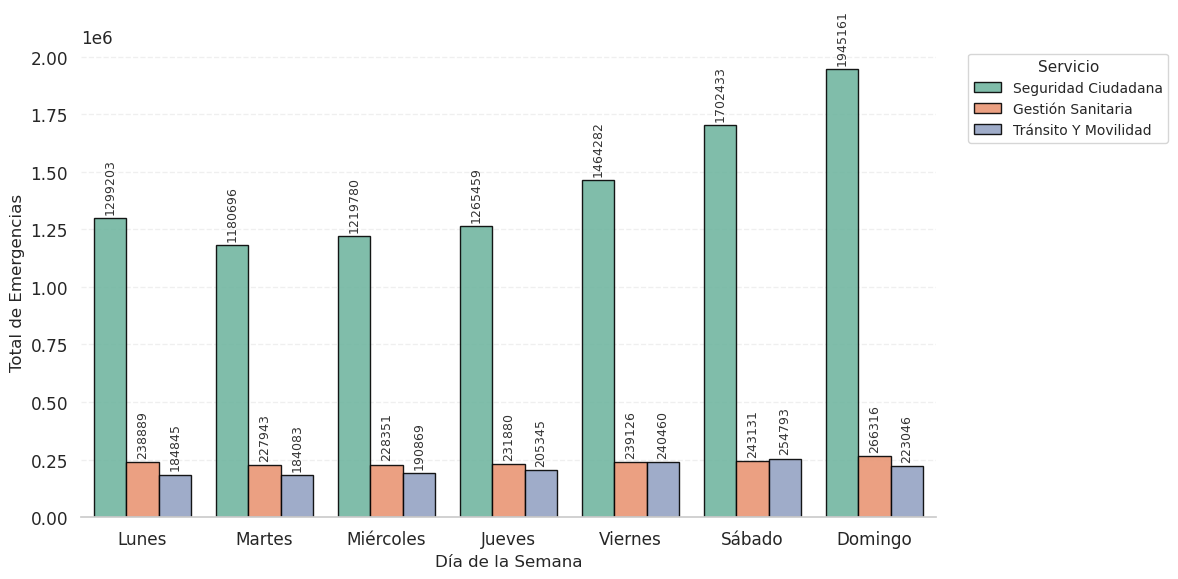

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Orden correcto de días
dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
top3_dia['nombre_dia'] = top3_dia['dia_semana'].map(dict(zip(range(7), dias)))
top3_dia['nombre_dia'] = pd.Categorical(top3_dia['nombre_dia'], categories=dias, ordered=True)

# Estilo visual
sns.set_theme(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=top3_dia,
    x='nombre_dia', y='cantidad_eventos', hue='servicio',
    palette='Set2', edgecolor='black', alpha=0.9
)

# Título y etiquetas
#plt.title("Top 3 Servicios Más Recurrentes por Día de la Semana (2021–2025)",
          #fontsize=16, weight='bold', pad=20)
plt.xlabel("Día de la Semana", fontsize=12)
plt.ylabel("Total de Emergencias", fontsize=12)

# Etiquetas numéricas rotadas 90°
for c in ax.containers:
    ax.bar_label(c, fmt='%d', label_type='edge',
                 fontsize=9, padding=3, color='#333', rotation=90)

# Leyenda
plt.legend(
    title="Servicio",
    title_fontsize=11,
    fontsize=10,
    frameon=True,
    fancybox=True,
    shadow=False,
    bbox_to_anchor=(1.03, 1),
    loc='upper left'
)

# Estilo final
sns.despine(left=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

# Guardar figura
plt.savefig("../reports/fig/top3_servicios_por_dia.png", bbox_inches="tight", transparent=False)

plt.show()


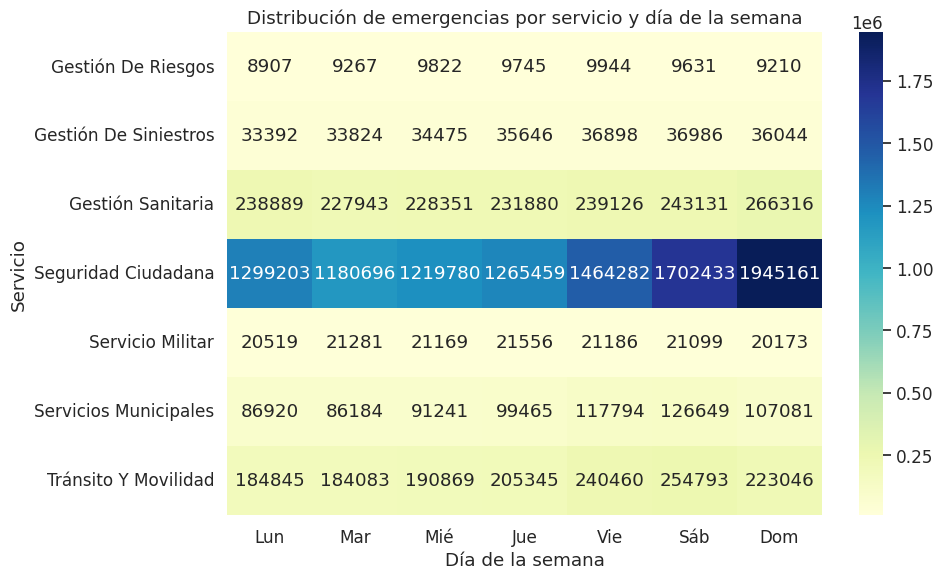

In [64]:
df_heat_serv = (
    df.groupby(['dia_semana', 'servicio'])['cantidad_eventos']
      .sum()
      .reset_index()
)

heatmap_serv = df_heat_serv.pivot(index='servicio', columns='dia_semana', values='cantidad_eventos')
heatmap_serv.columns = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_serv, cmap='YlGnBu', annot=True, fmt=".0f")
plt.title("Distribución de emergencias por servicio y día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Servicio")
plt.tight_layout()
plt.show()


In [65]:
# Cargar feriados
feriados = pd.read_csv("../data/feriados_ecuador_2021_2025.csv", parse_dates=["fecha_feriado"])

# Marcar en tu DataFrame principal
df['es_feriado'] = df['fecha'].isin(feriados['fecha_feriado']).astype(int)

# Verificar
df[df['es_feriado'] == 1].head()


,fecha,provincia,canton,cod_parroquia,parroquia,servicio,subtipo,cantidad_eventos,periodo,dia_semana,es_feriado
47328,2022-04-15,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Seguridad Ciudadana,Escándalo En Espacio Privado,2,2021–2022,4,1
47329,2022-04-15,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Seguridad Ciudadana,Escándalo En Espacio Público,1,2021–2022,4,1
47330,2022-04-15,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Seguridad Ciudadana,Patrullaje Policial En El Sector Solicitado,4,2021–2022,4,1
47331,2022-04-15,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Tránsito Y Movilidad,Accidente De Tránsito Sin Heridos,1,2021–2022,4,1
47332,2022-04-15,Azuay,Chordeleg,11150,"Chordeleg, Cabecera Cantonal",Gestión De Siniestros,Vehiculares,1,2021–2022,4,1


In [66]:
feriados

,fecha_original,fecha_feriado,descripcion,es_trasladado,anio
0,2021-08-10,2021-08-09,Primer Grito de Independencia,True,2021
1,2021-10-09,2021-10-09,Independencia de Guayaquil,False,2021
2,2021-11-02,2021-11-02,Día de los Difuntos,False,2021
3,2021-11-03,2021-11-03,Independencia de Cuenca,False,2021
4,2021-12-25,2021-12-25,Navidad,False,2021
5,2022-01-01,2022-01-01,Año Nuevo,False,2022
6,2022-02-28,2022-02-28,Carnaval,False,2022
7,2022-03-01,2022-03-01,Carnaval,False,2022
8,2022-04-15,2022-04-15,Viernes Santo,False,2022
9,2022-05-01,2022-05-02,Día del Trabajo (traslado),True,2022


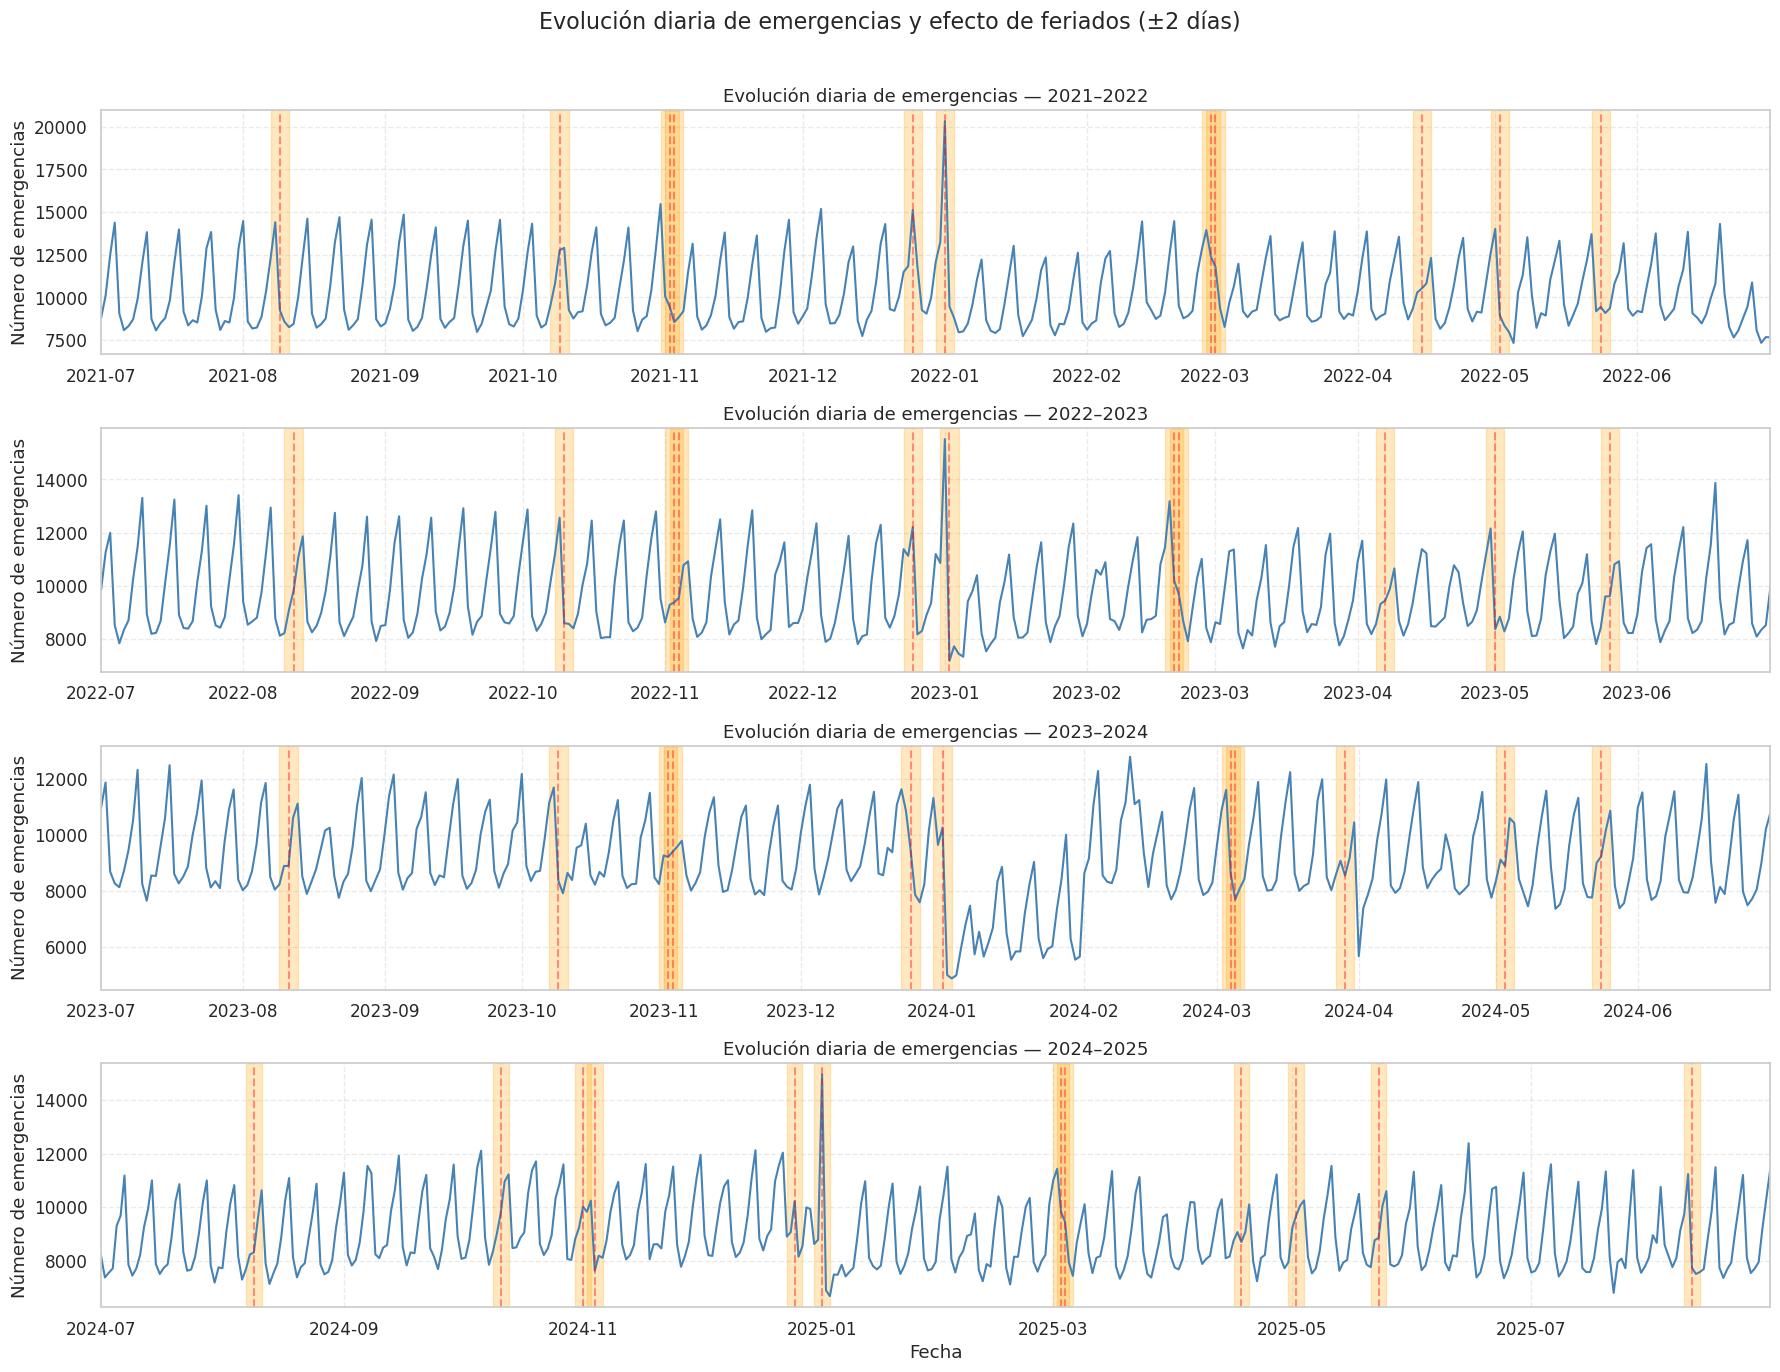

In [68]:
# Asegurar formato de fecha
df['fecha'] = pd.to_datetime(df['fecha'])

# Agrupar total diario de emergencias por fecha y periodo
df_diario_total = (
    df.groupby(['fecha', 'periodo'])['cantidad_eventos']
      .sum()
      .reset_index()
      .sort_values('fecha')
)

# Extraer las fechas feriadas únicas
feriados = df[df['es_feriado'] == 1]['fecha'].unique()
feriados = pd.to_datetime(feriados)

# Crear paneles (uno por periodo)
periodos = ['2021–2022', '2022–2023', '2023–2024', '2024–2025']
fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharey=False)

for i, periodo in enumerate(periodos):
    ax = axes[i]
    
    # Datos por año
    sub = df_diario_total[df_diario_total['periodo'] == periodo]
    ax.plot(sub['fecha'], sub['cantidad_eventos'], color='steelblue', linewidth=1.5)
    ax.set_title(f"Evolución diaria de emergencias — {periodo}", fontsize=13)
    ax.set_ylabel("Número de emergencias")
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # Feriados dentro de ese rango
    fer_sub = [f for f in feriados if sub['fecha'].min() <= f <= sub['fecha'].max()]
    
    # Sombrear ±2 días
    for f in fer_sub:
        inicio = f - pd.Timedelta(days=2)
        fin = f + pd.Timedelta(days=2)
        ax.axvspan(inicio, fin, color='orange', alpha=0.25)
        ax.axvline(f, color='red', linestyle='--', alpha=0.4)
    
    ax.set_xlim(sub['fecha'].min(), sub['fecha'].max())

axes[-1].set_xlabel("Fecha")
plt.suptitle("Evolución diaria de emergencias y efecto de feriados (±2 días)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("../reports/fig/evolcion_diaria_feriados.png", bbox_inches="tight", transparent=False)

plt.show()


In [71]:
df_diario_total

,fecha,periodo,cantidad_eventos
0,2021-07-01,2021–2022,8773
1,2021-07-02,2021–2022,10096
2,2021-07-03,2021–2022,12482
3,2021-07-04,2021–2022,14381
4,2021-07-05,2021–2022,9047
...,...,...,...
1518,2025-08-27,2024–2025,7716
1519,2025-08-28,2024–2025,7954
1520,2025-08-29,2024–2025,9252
1521,2025-08-30,2024–2025,10366


In [ ]:
df.to_parquet("../data/ecu911_emergencias_limpio2.parquet", index=False)

In [69]:
df.head()

,fecha,provincia,canton,cod_parroquia,parroquia,servicio,subtipo,cantidad_eventos,periodo,dia_semana,es_feriado
0,2022-04-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Gestión Sanitaria,Problemas En El Embarazo,1,2021–2022,4,0
1,2022-04-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Seguridad Ciudadana,Patrullaje Policial En El Sector Solicitado,1,2021–2022,4,0
2,2022-04-01,Azuay,Camilo Ponce Enriquez,11550,"Camilo Ponce Enríquez, Cabecera Cantonal",Seguridad Ciudadana,Resguardo A Personas Que Traslada Valores A Ni...,1,2021–2022,4,0
3,2022-04-01,Azuay,Chordeleg,11150,"Chordeleg, Cabecera Cantonal",Seguridad Ciudadana,Patrullaje Policial En El Sector Solicitado,1,2021–2022,4,0
4,2022-04-01,Azuay,Cuenca,10150,"Cuenca, Cabecera Cantonal Y Capital Provincial.",Gestión De Riesgos,Amenazas Naturales,1,2021–2022,4,0
